# Lab 02 - Bài tập

## THÔNG TIN SINH VIÊN

- Họ tên: Nguyễn Nam Trung Nguyên
- MSV: 23640731


Sinh viên ghi số bài làm được vào ô dưới đây:

## KẾT QUẢ: 10/10 bài

---

In [1]:
# Run this cell first to import the libraries we will use
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## PANDAS

Bạn hãy tạo một DataFrame có tên `df_sales` chứa thông tin các sản phẩm:

In [3]:
sales_data = {
    'product_id': ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008'],
    'product_name': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Tablet', 'Phone', 'Headphones', 'Webcam'],
    'category': ['Electronics', 'Accessories', 'Accessories', 'Electronics', 'Electronics', 'Electronics', 'Accessories', 'Accessories'],
    'price': [999, 25, 75, 299, 499, 699, 129, 89],
    'units_sold': [15, 120, 85, 35, 28, 45, 67, 23],
    'supplier': ['TechCorp', 'AccessCo', 'AccessCo', 'TechCorp', 'MobileTech', 'MobileTech', 'AudioTech', 'CameraCo']
}

df_sales = pd.DataFrame(sales_data)

### 1. Hiểu dữ liệu

a. Kích thước của dữ liệu?

b. Tên các cột?

c. Hiển thị 3 dòng đầu tiên và 3 dòng cuối cùng

d. Thống kê mô tả các biến định lượng

In [7]:
# YOUR CODE HERE
# a. Kích thước dữ liệu
df_sales.shape

(8, 6)

In [8]:
# b. Tên các cột?
df_sales.columns

Index(['product_id', 'product_name', 'category', 'price', 'units_sold',
       'supplier'],
      dtype='object')

In [11]:
# c. Hiển thị 3 dòng đầu tiên 
df_sales.head(3)

,product_id,product_name,category,price,units_sold,supplier
0,P001,Laptop,Electronics,999,15,TechCorp
1,P002,Mouse,Accessories,25,120,AccessCo
2,P003,Keyboard,Accessories,75,85,AccessCo


In [10]:
# 3 dòng cuối cùng
df_sales.tail(3)

,product_id,product_name,category,price,units_sold,supplier
5,P006,Phone,Electronics,699,45,MobileTech
6,P007,Headphones,Accessories,129,67,AudioTech
7,P008,Webcam,Accessories,89,23,CameraCo


In [12]:
# d. Thống kê mô tả các biến định lượng
df_sales.describe()

,price,units_sold
count,8.00000,8.000000
mean,351.75000,52.250000
std,351.72869,35.979161
min,25.00000,15.000000
25%,85.50000,26.750000
50%,214.00000,40.000000
75%,549.00000,71.500000
max,999.00000,120.000000


### 2. Lọc dữ liệu

a. Lọc các cột sau: 'product_name', 'price', and 'units_sold'

b. Lọc các sản phẩm có giá trên 100

c. Tìm các sản phẩm điện tử ('Electronics') với số lượng bán trên 30

d. Tìm những sản phẩm phụ kiện (`Accessories`) có giá từ 50 đến 100

In [13]:
# YOUR CODE HERE
# a. Lọc các cột sau: 'product_name', 'price', and 'units_sold'
df_sales[['product_name', 'price', 'units_sold']]

,product_name,price,units_sold
0,Laptop,999,15
1,Mouse,25,120
2,Keyboard,75,85
3,Monitor,299,35
4,Tablet,499,28
5,Phone,699,45
6,Headphones,129,67
7,Webcam,89,23


In [14]:
# b. Lọc các sản phẩm có giá trên 100
df_sales[df_sales['price'] > 100]

,product_id,product_name,category,price,units_sold,supplier
0,P001,Laptop,Electronics,999,15,TechCorp
3,P004,Monitor,Electronics,299,35,TechCorp
4,P005,Tablet,Electronics,499,28,MobileTech
5,P006,Phone,Electronics,699,45,MobileTech
6,P007,Headphones,Accessories,129,67,AudioTech


In [15]:
# c. Sản phẩm Electronics và units_sold > 30
df_sales[
    (df_sales['category'] == 'Electronics') &
    (df_sales['units_sold'] > 30)
]

,product_id,product_name,category,price,units_sold,supplier
3,P004,Monitor,Electronics,299,35,TechCorp
5,P006,Phone,Electronics,699,45,MobileTech


In [17]:
# d. Accessories có giá từ 50 đến 100
# Cách 1
# df_sales[
#     (df_sales['category'] == 'Accessories') &
#     (df_sales['price'] >= 50) &
#     (df_sales['price'] <= 100)
# ]
# Cách 2
df_sales[
    (df_sales['category'] == 'Accessories') &
    (df_sales['price'].between(50, 100))
]

,product_id,product_name,category,price,units_sold,supplier
2,P003,Keyboard,Accessories,75,85,AccessCo
7,P008,Webcam,Accessories,89,23,CameraCo


### 3. Tạo cột mới

Tao thêm các cột sau:

a. Tạo cột doanh thu `revenue` = `price` * `units_sold`

b. Tạo cột `price_category` dựa trên giá của sản phẩm:
   - 'Low' nếu giá < 100
   - 'Medium' nếu 1000 <= giá <= 500
   - 'High' nếu giá > 500

c. Tạo cộ `high_performer`:  True if units_sold > median(units_sold)

In [21]:
# YOUR CODE HERE
# a. Tạo cột doanh thu revenue = price * units_sold
df_sales['revenue'] = df_sales['price'] * df_sales['units_sold']
df_sales

,product_id,product_name,category,price,units_sold,supplier,revenue
0,P001,Laptop,Electronics,999,15,TechCorp,14985
1,P002,Mouse,Accessories,25,120,AccessCo,3000
2,P003,Keyboard,Accessories,75,85,AccessCo,6375
3,P004,Monitor,Electronics,299,35,TechCorp,10465
4,P005,Tablet,Electronics,499,28,MobileTech,13972
5,P006,Phone,Electronics,699,45,MobileTech,31455
6,P007,Headphones,Accessories,129,67,AudioTech,8643
7,P008,Webcam,Accessories,89,23,CameraCo,2047


In [22]:
# b. Tạo cột price_category dựa trên giá của sản phẩm:
    # 'Low' nếu giá < 100
    # 'Medium' nếu 1000 <= giá <= 500
    # 'High' nếu giá > 500
    
def price_category(price):
    if price < 100:
        return 'Low'
    elif price <= 500:
        return 'Medium'
    else:
        return 'High'

df_sales['price_category'] = df_sales['price'].apply(price_category)
df_sales

,product_id,product_name,category,price,units_sold,supplier,revenue,price_category
0,P001,Laptop,Electronics,999,15,TechCorp,14985,High
1,P002,Mouse,Accessories,25,120,AccessCo,3000,Low
2,P003,Keyboard,Accessories,75,85,AccessCo,6375,Low
3,P004,Monitor,Electronics,299,35,TechCorp,10465,Medium
4,P005,Tablet,Electronics,499,28,MobileTech,13972,Medium
5,P006,Phone,Electronics,699,45,MobileTech,31455,High
6,P007,Headphones,Accessories,129,67,AudioTech,8643,Medium
7,P008,Webcam,Accessories,89,23,CameraCo,2047,Low


In [23]:
# c. Tạo cộ high_performer: True if units_sold > median(units_sold)
median_units = df_sales['units_sold'].median()
df_sales['high_performer'] = df_sales['units_sold'] > median_units
df_sales

,product_id,product_name,category,price,units_sold,supplier,revenue,price_category,high_performer
0,P001,Laptop,Electronics,999,15,TechCorp,14985,High,False
1,P002,Mouse,Accessories,25,120,AccessCo,3000,Low,True
2,P003,Keyboard,Accessories,75,85,AccessCo,6375,Low,True
3,P004,Monitor,Electronics,299,35,TechCorp,10465,Medium,False
4,P005,Tablet,Electronics,499,28,MobileTech,13972,Medium,False
5,P006,Phone,Electronics,699,45,MobileTech,31455,High,True
6,P007,Headphones,Accessories,129,67,AudioTech,8643,Medium,True
7,P008,Webcam,Accessories,89,23,CameraCo,2047,Low,False


### 4. Xử lý dữ liệu thiếu

Khởi tạo một DataFrame về dữ liệu khảo sát dưới đây và thực hiện các yêu cầu::

a. Hiển thị số lượng giá trị thiếu trong mỗi cột và phần trăm giá trị thiếu

b. Tạo một bản sao chứa dữ liệu đã loại bỏ các dòng có giá trị thiếu

c. Tạo một bản sao chứa các giá trị định lượng bị thiếu đã được thay thế bằng giá trị trung bình của cột đó

d. Tạo một bản sao chứa dữ liệu thiếu ở cột `city` được thay thế bằng giá trị phổ biến nhất (mode) của cột đó

In [24]:
# Create dataset with missing values
survey_data = {
    'respondent_id': range(1, 11),
    'age': [25, 30, None, 35, 28, None, 45, 32, 29, 38],
    'income': [50000, None, 45000, 60000, None, 55000, 75000, None, 48000, 62000],
    'satisfaction': [4, 5, 3, None, 4, 5, None, 3, 4, 5],
    'city': ['NYC', 'LA', 'Chicago', None, 'NYC', 'LA', 'Chicago', 'NYC', None, 'LA']
}

df_survey = pd.DataFrame(survey_data)

In [30]:
# YOUR CODE HERE
# a. Hiển thị số lượng giá trị thiếu trong mỗi cột và phần trăm giá trị thiếu
missing_count = df_survey.isnull().sum()
missing_percent = df_survey.isnull().mean() * 100

print("Số lượng giá trị thiếu:")
print(missing_count)

print("\nPhần trăm giá trị thiếu:")
print(missing_percent)

Số lượng giá trị thiếu:
respondent_id    0
age              2
income           3
satisfaction     2
city             2
dtype: int64

Phần trăm giá trị thiếu:
respondent_id     0.0
age              20.0
income           30.0
satisfaction     20.0
city             20.0
dtype: float64


In [31]:
# b. Tạo một bản sao chứa dữ liệu đã loại bỏ các dòng có giá trị thiếu
df_dropna = df_survey.dropna().copy()

print("Dữ liệu sau khi bỏ dòng thiếu:")
print(df_dropna)

Dữ liệu sau khi bỏ dòng thiếu:
   respondent_id   age   income  satisfaction city
0              1  25.0  50000.0           4.0  NYC
9             10  38.0  62000.0           5.0   LA


In [32]:
# c. Tạo một bản sao chứa các giá trị định lượng bị thiếu đã được thay thế bằng giá trị trung bình của cột đó
df_fill_mean = df_survey.copy()

for col in ['age', 'income', 'satisfaction']:
    df_fill_mean[col].fillna(df_fill_mean[col].mean(), inplace=True)

print("Dữ liệu sau khi điền trung bình:")
print(df_fill_mean)

Dữ liệu sau khi điền trung bình:
   respondent_id    age        income  satisfaction     city
0              1  25.00  50000.000000         4.000      NYC
1              2  30.00  56428.571429         5.000       LA
2              3  32.75  45000.000000         3.000  Chicago
3              4  35.00  60000.000000         4.125     None
4              5  28.00  56428.571429         4.000      NYC
5              6  32.75  55000.000000         5.000       LA
6              7  45.00  75000.000000         4.125  Chicago
7              8  32.00  56428.571429         3.000      NYC
8              9  29.00  48000.000000         4.000     None
9             10  38.00  62000.000000         5.000       LA


In [33]:
# d. Tạo một bản sao chứa dữ liệu thiếu ở cột city được thay thế bằng giá trị phổ biến nhất (mode) của cột đó
df_fill_city = df_survey.copy()

mode_city = df_fill_city['city'].mode()[0]
df_fill_city['city'].fillna(mode_city, inplace=True)

print("Dữ liệu sau khi điền city bằng mode:")
print(df_fill_city)

Dữ liệu sau khi điền city bằng mode:
   respondent_id   age   income  satisfaction     city
0              1  25.0  50000.0           4.0      NYC
1              2  30.0      NaN           5.0       LA
2              3   NaN  45000.0           3.0  Chicago
3              4  35.0  60000.0           NaN       LA
4              5  28.0      NaN           4.0      NYC
5              6   NaN  55000.0           5.0       LA
6              7  45.0  75000.0           NaN  Chicago
7              8  32.0      NaN           3.0      NYC
8              9  29.0  48000.0           4.0       LA
9             10  38.0  62000.0           5.0       LA


### 5. Gom nhóm và tổng hợp

Sử dụng DataFrame `df_sales` đã tạo ở trên và thực hiện các yêu cầu:

a. Tính giá trung bình và tổng doanh thu theo từng loại sản phẩm (`category`)

b. Đếm số sản phẩm theo từng nhà cung cấp (`supplier`)

c. Tính min, max, mean và độ lệch chuẩn về giá theo từng loại sản phẩm (`category`)

d. Tính miền giá trị (range) về số lượng sản phẩm đã bán (`units_sold) theo từng nhà cung cấp (`supplier`)

In [34]:
# YOUR CODE HERE
# a. Tính giá trung bình và tổng doanh thu theo từng loại sản phẩm (category)
result_a = df_sales.groupby('category').agg({
    'price': 'mean',
    'revenue': 'sum'
})

print(result_a)

             price  revenue
category                   
Accessories   79.5    20065
Electronics  624.0    70877


In [35]:
# b. Đếm số sản phẩm theo từng nhà cung cấp (supplier)
result_b = df_sales['supplier'].value_counts()

print(result_b)

AccessCo      2
MobileTech    2
TechCorp      2
AudioTech     1
CameraCo      1
Name: supplier, dtype: int64


In [36]:
# c. Tính min, max, mean và độ lệch chuẩn về giá theo từng loại sản phẩm (category)
result_c = df_sales.groupby('category')['price'].agg(
    ['min', 'max', 'mean', 'std']
)

print(result_c)

             min  max   mean         std
category                                
Accessories   25  129   79.5   42.937940
Electronics  299  999  624.0  298.607881


In [37]:
# d. Tính miền giá trị (range) về số lượng sản phẩm đã bán (units_sold) theo từng nhà cung cấp (supplier`)
result_d = df_sales.groupby('supplier')['units_sold'].agg(
    lambda x: x.max() - x.min()
)

print(result_d)

supplier
AccessCo      35
AudioTech      0
CameraCo       0
MobileTech    17
TechCorp      20
Name: units_sold, dtype: int64


---

## STATISTICAL ANALYSIS



### 6. Xu hướng tập trung

Cho 4 datasets sau, với mỗi dataset bạn hãy lựa chọn độ đo thích hợp để mô tả xu hướng tập trung của dữ liệu và giải thích lý do:

In [38]:
# Create sample datasets for different scenarios
dataset1 = [85, 87, 90, 92, 95, 88, 91, 89, 86, 93]  # Symmetric
dataset2 = [25000, 28000, 30000, 32000, 150000, 29000, 31000, 27000, 33000, 26000]  # Right-skewed
dataset3 = [1.05, 0.98, 1.12, 0.95, 1.08, 1.03, 0.92, 1.15, 1.07, 0.99]  # Growth factors
dataset4 = ['Red', 'Blue', 'Blue', 'Green', 'Blue', 'Red', 'Yellow', 'Blue', 'Green', 'Blue']  # Categorical

print("TASK: For each dataset, calculate appropriate measures of central tendency and explain your choice:")
print("Dataset 1 (Test scores):", dataset1)
print("Dataset 2 (Salaries):", dataset2) 
print("Dataset 3 (Growth rates):", dataset3)
print("Dataset 4 (Colors):", dataset4)

TASK: For each dataset, calculate appropriate measures of central tendency and explain your choice:
Dataset 1 (Test scores): [85, 87, 90, 92, 95, 88, 91, 89, 86, 93]
Dataset 2 (Salaries): [25000, 28000, 30000, 32000, 150000, 29000, 31000, 27000, 33000, 26000]
Dataset 3 (Growth rates): [1.05, 0.98, 1.12, 0.95, 1.08, 1.03, 0.92, 1.15, 1.07, 0.99]
Dataset 4 (Colors): ['Red', 'Blue', 'Blue', 'Green', 'Blue', 'Red', 'Yellow', 'Blue', 'Green', 'Blue']


**YOUR ANSWER HERE**

In [39]:
# YOUR CODE HERE
# Dataset 1 (Test scores): [85, 87, 90, 92, 95, 88, 91, 89, 86, 93]
# Dữ liệu khá đều, không có outlier → dùng Mean
# Phân bố đối xứng → Mean phản ánh tốt trung tâm dữ liệu.

import numpy as np

np.mean(dataset1)

89.6

In [40]:
# Dataset 2 (Salaries): [25000, 28000, 30000, 32000, 150000, 29000, 31000, 27000, 33000, 26000]
# Có giá trị 150000 quá lớn → dùng Median
# Median không bị ảnh hưởng bởi outlier → phù hợp hơn mean.
np.median(dataset2)

29500.0

In [41]:
# Dataset 3 (Growth rates): [1.05, 0.98, 1.12, 0.95, 1.08, 1.03, 0.92, 1.15, 1.07, 0.99]
# Các số nhỏ, gần nhau → dùng Mean
# Không có giá trị dị biệt lớn → Mean đại diện tốt.
np.mean(dataset3)

1.0340000000000003

In [42]:
# Dataset 4 (Colors): ['Red', 'Blue', 'Blue', 'Green', 'Blue', 'Red', 'Yellow', 'Blue', 'Green', 'Blue']
# Dữ liệu dạng chữ → dùng Mode
# Dữ liệu định tính không tính mean/median → chỉ dùng Mode (giá trị xuất hiện nhiều nhất).
from collections import Counter

Counter(dataset4).most_common(1)

[('Blue', 5)]

### 7. Độ đo phân tán

Cho một bộ dữ liệu mẫu `sample_data`, bạn hãy thực hiện:

a. Tính phương sai tổng thể (giả sử như sample_data là toàn bộ tổng thể)
b. Tính phương sai mẫu (giả sử như sample_data là một mẫu từ tổng thể lớn hơn)
c. Giải thích sự khác biệt giữa phương sai tổng thể và phương sai mẫu. Giải thích khái niệm bậc tự do (degrees of freedom) trong tính toán phương sai mẫu.
d. Tính các đại lượng: miền giá trị (range), miền phân vị (IQR) và hệ số biến thiên (coefficient of variation - CV) . Bạn hãy trình bày ý nghĩa của mỗi đại lượng.

In [48]:
sample_data = [12, 15, 18, 21, 24, 27, 30]

**YOUR ANSWER HERE**

In [50]:
# YOUR CODE HERE
# a. Tính phương sai tổng thể (giả sử như sample_data là toàn bộ tổng thể) 
import numpy as np

data = np.array([12, 15, 18, 21, 24, 27, 30])
print(np.var(data))

36.0


In [51]:
# b. Tính phương sai mẫu (giả sử như sample_data là một mẫu từ tổng thể lớn hơn)
import numpy as np

data = np.array([12, 15, 18, 21, 24, 27, 30])
print(np.var(data, ddof=1))

42.0


In [ ]:
# c. Giải thích sự khác biệt giữa phương sai tổng thể và phương sai mẫu. Giải thích khái niệm bậc tự do (degrees of freedom) trong tính toán phương sai mẫu.
# Khác nhau giữa phương sai tổng thể và mẫu
# Loại                   Chia cho       Dùng khi
# Phương sai tổng thể    N              Có toàn bộ dữ liệu
# Phương sai mẫu         N − 1          Chỉ có 1 mẫu đại diện
# Phương sai mẫu lớn hơn vì phải bù sai số do chỉ lấy mẫu.

In [52]:
# d. Tính các đại lượng: miền giá trị (range)
print(max(data) - min(data))
# Ý nghĩa: Độ trải rộng đơn giản nhất của dữ liệu.

18


In [53]:
# d. Tính các đại lượng miền phân vị (IQR) 
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
print(q3 - q1)
# Ý nghĩa: Độ phân tán của 50% dữ liệu ở giữa, ít bị ảnh hưởng bởi outlier.

9.0


In [54]:
# d. Tính các đại lượng hệ số biến thiên (coefficient of variation - CV) 
print(np.std(data) / np.mean(data))
# Ý nghĩa:
    # So sánh mức độ biến động giữa các bộ dữ liệu khác đơn vị.
    # CV càng lớn → dữ liệu càng phân tán.

0.2857142857142857


8. Thống kê

Chạy câu lệnh bên dưới để sinh dữ liệu `exam_scores` gồm 50 điểm thi của sinh viên trong một kỳ thi. 
    Thực hiện các yêu cầu:
a. Tính các đại lượng thống kê cơ bản của mỗi môn học
b. Với mỗi môn học, xác định độ đo phù hợp để mô tả xu hướng tập trung và độ đo phân tán của điểm thi. Giải thích lý do.
c. Tạo một bảng thống kê tóm tắt (summary table) cho mỗi môn học, bao gồm các đại lượng thống kê đã tính ở trên.

In [56]:
# Load a real dataset for comprehensive analysis
exam_scores = pd.DataFrame({
    'student_id': range(1, 51),
    'math_score': np.random.normal(75, 12, 50).astype(int),
    'english_score': np.random.normal(80, 10, 50).astype(int),
    'science_score': np.random.normal(78, 15, 50).astype(int),
    'total_score': lambda x: x.math_score + x.english_score + x.science_score
})

In [59]:
# YOUR CODE HERE
# a. Tính các đại lượng thống kê cơ bản của mỗi môn học
exam_scores[['math_score','english_score','science_score','total_score']].describe()

,math_score,english_score,science_score
count,50.000000,50.000000,50.000000
mean,75.000000,76.280000,71.340000
std,10.898418,11.750884,15.692986
min,53.000000,47.000000,39.000000
25%,68.500000,67.000000,59.250000
50%,77.000000,77.500000,70.000000
75%,81.000000,84.750000,83.000000
max,103.000000,100.000000,111.000000


In [ ]:
# b. Với mỗi môn học, xác định độ đo phù hợp để mô tả xu hướng tập trung và độ đo phân tán của điểm thi. Giải thích lý do.
Độ đo xu hướng tập trung: Mean (Trung bình)
    Vì điểm thi là dữ liệu số và thường phân bố khá đều, mean phản ánh mức điểm chung của lớp.

Độ đo phân tán: Standard Deviation (Độ lệch chuẩn)
    Vì cho biết mức độ chênh lệch điểm quanh giá trị trung bình và dễ hiểu do cùng đơn vị điểm.

In [60]:
# c. Tạo một bảng thống kê tóm tắt (summary table) cho mỗi môn học, bao gồm các đại lượng thống kê đã tính ở trên.
summary_table = exam_scores[['math_score','english_score','science_score','total_score']].agg([
    'mean',
    'median',
    'std',
    'var',
    'min',
    'max'
])

print(summary_table)

        math_score  english_score  science_score
mean     75.000000      76.280000      71.340000
median   77.000000      77.500000      70.000000
std      10.898418      11.750884      15.692986
var     118.775510     138.083265     246.269796
min      53.000000      47.000000      39.000000
max     103.000000     100.000000     111.000000


---

## SEABORN

### 9. `tips` dataset

Sử dụng dataset `tips` từ seaborn, bạn hãy thực hiện:

a. Khám phá cấu trúc của dataset và xử lý giá trị thiếu (nếu có)

b. Tính các đại lượng thống kê cơ bản cho tất cả các biến

c. So sánh tiền tip trung bình giữa các nhóm khác nhau theo ngày, thời gian (day, time)

d. Phân tích mối quan hệ giữa tổng hóa đơn (total_bill) và tiền tip (tip)

e. Vẽ histogram của tiền tip

f. Vẽ box plot để so sánh tiền tip giữa các ngày trong tuần

In [65]:
# YOUR CODE HERE
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
# a. Khám phá cấu trúc của dataset và xử lý giá trị thiếu (nếu có)
tips = sns.load_dataset("tips")

print(tips.head())
print(tips.info())
print(tips.isnull().sum())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
total_bill    244 non-null float64
tip           244 non-null float64
sex           244 non-null category
smoker        244 non-null category
day           244 non-null category
time          244 non-null category
size          244 non-null int64
dtypes: category(4), float64(2), int64(1)
memory usage: 7.2 KB
None
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [67]:
# b. Tính các đại lượng thống kê cơ bản cho tất cả các biến
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [73]:
# c. So sánh tiền tip trung bình giữa các nhóm khác nhau theo ngày, thời gian (day, time)
tips.groupby(['day', 'time'])['tip'].mean()

day   time  
Thur  Lunch     2.767705
      Dinner    3.000000
Fri   Lunch     2.382857
      Dinner    2.940000
Sat   Dinner    2.993103
Sun   Dinner    3.255132
Name: tip, dtype: float64

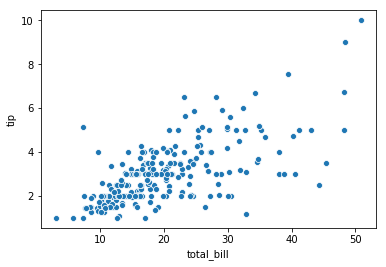

In [74]:
# d. Phân tích mối quan hệ giữa tổng hóa đơn (total_bill) và tiền tip (tip)
sns.scatterplot(data=tips, x='total_bill', y='tip')
plt.show()
# Nhận xét: Hóa đơn càng cao → tip thường tăng (tương quan dương).

In [4]:
# e. Vẽ histogram của tiền tip


In [6]:
# f. Vẽ box plot để so sánh tiền tip giữa các ngày trong tuần


### 10. A dataset of Seaborn

Chọn một dataset bất kỳ từ thư viện Seaborn (ngoài `tips` đã sử dụng ở trên) và thực hiện các bước sau:

a. Tìm hiểu thông tin về dataset đã chọn

b. Sử dụng kiến thức đã học để phân tích và trình bày các kết quả mà bạn khám phá được từ bộ dữ liệu trên

In [8]:
# a. Tìm hiểu thông tin về dataset đã chọn
import seaborn as sns

iris = sns.load_dataset("iris")

iris.head()
iris.info()
iris.describe()
iris.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_length    150 non-null float64
sepal_width     150 non-null float64
petal_length    150 non-null float64
petal_width     150 non-null float64
species         150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [10]:
# YOUR CODE HERE
# b. Sử dụng kiến thức đã học để phân tích và trình bày các kết quả mà bạn khám phá được từ bộ dữ liệu trên
# 1. Trung bình theo loài
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
# Nhận xét:
# setosa có cánh hoa (petal) nhỏ nhất
# virginica có kích thước lớn nhất.

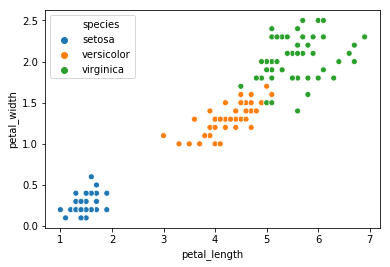

In [11]:
# 2. Mối quan hệ chiều dài & chiều rộng cánh hoa
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')

In [ ]:
# Nhận xét:
#     Các loài tách biệt khá rõ.
#     setosa tách hoàn toàn khỏi 2 loài còn lại

In [14]:
# 3. Phân bố chiều dài cánh hoa
# sns.histplot(iris['petal_length'])

In [ ]:
# Nhận xét:
# Dữ liệu không đối xứng, có 3 cụm → tương ứng 3 loài.

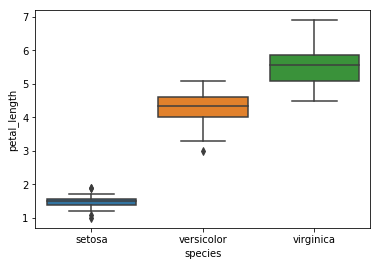

In [13]:
# 4. Boxplot so sánh theo loài
sns.boxplot(data=iris, x='species', y='petal_length')

In [ ]:
# Nhận xét:
#     Petal length & width là biến phân biệt loài tốt nhất.
#     Setosa nhỏ nhất, Virginica lớn nhất.
#     Dataset sạch, dễ dùng cho bài toán phân loại (classification).


---

## CHANGELOG

- 20250831: new version
- ...

---